In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/syedaeman2212/airline-ticket-prices-dataset/airline_ticket_prices_dataset.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/syedaeman2212/airline-ticket-prices-dataset/airline_ticket_prices_dataset.csv')

In [4]:
print(df.head())
print(df.shape)

   Ticket_ID          Airline    Origin Destination  Distance_km     Class  \
0          1           Saudia    Mumbai       Paris         2643   Economy   
1          2           Etihad  Istanbul      Jeddah         8266  Business   
2          3  British Airways     Dubai      Riyadh         2698     First   
3          4         Emirates    London    Istanbul         7956     First   
4          5    Qatar Airways      Doha       Dubai         1308  Business   

   Days_Before_Departure  Price_USD  
0                     28     555.30  
1                     98    2070.27  
2                     21    1883.11  
3                     24    5349.65  
4                     60     516.19  
(250, 8)


## Dataset Overview

This dataset contains airline ticket pricing information including airline, origin, destination, flight distance, ticket class, booking timing, and ticket price.

The goal of this analysis is to understand the factors that influence airline ticket prices and explore whether ticket prices can be predicted using available features.

In [5]:
# Summary statistics
df.describe()

,Ticket_ID,Distance_km,Days_Before_Departure,Price_USD
count,250.000000,250.000000,250.000000,250.000000
mean,125.500000,5999.952000,59.024000,2006.059760
std,72.312977,3401.695261,33.736628,1675.067217
min,1.000000,336.000000,1.000000,106.070000
25%,63.250000,2991.750000,31.250000,818.665000
50%,125.500000,6132.500000,60.500000,1531.235000
75%,187.750000,8832.750000,86.750000,2590.357500
max,250.000000,11903.000000,118.000000,8852.690000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Ticket_ID              250 non-null    int64  
 1   Airline                250 non-null    object 
 2   Origin                 250 non-null    object 
 3   Destination            250 non-null    object 
 4   Distance_km            250 non-null    int64  
 5   Class                  250 non-null    object 
 6   Days_Before_Departure  250 non-null    int64  
 7   Price_USD              250 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 15.8+ KB


In [7]:
df.nunique()

Ticket_ID                250
Airline                    8
Origin                    10
Destination               10
Distance_km              249
Class                      3
Days_Before_Departure    106
Price_USD                250
dtype: int64

In [8]:
df.isnull().sum()

Ticket_ID                0
Airline                  0
Origin                   0
Destination              0
Distance_km              0
Class                    0
Days_Before_Departure    0
Price_USD                0
dtype: int64

No missing values were found in the dataset, meaning no imputation or cleaning was required.

In [9]:
# Create route column
df["Route"] = df["Origin"] + " → " + df["Destination"]

# Price per km
df["Price_per_km"] = df["Price_USD"] / df["Distance_km"]

df.head()

,Ticket_ID,Airline,Origin,Destination,Distance_km,Class,Days_Before_Departure,Price_USD,Route,Price_per_km
0,1,Saudia,Mumbai,Paris,2643,Economy,28,555.30,Mumbai → Paris,0.210102
1,2,Etihad,Istanbul,Jeddah,8266,Business,98,2070.27,Istanbul → Jeddah,0.250456
2,3,British Airways,Dubai,Riyadh,2698,First,21,1883.11,Dubai → Riyadh,0.697965
3,4,Emirates,London,Istanbul,7956,First,24,5349.65,London → Istanbul,0.672404
4,5,Qatar Airways,Doha,Dubai,1308,Business,60,516.19,Doha → Dubai,0.394641


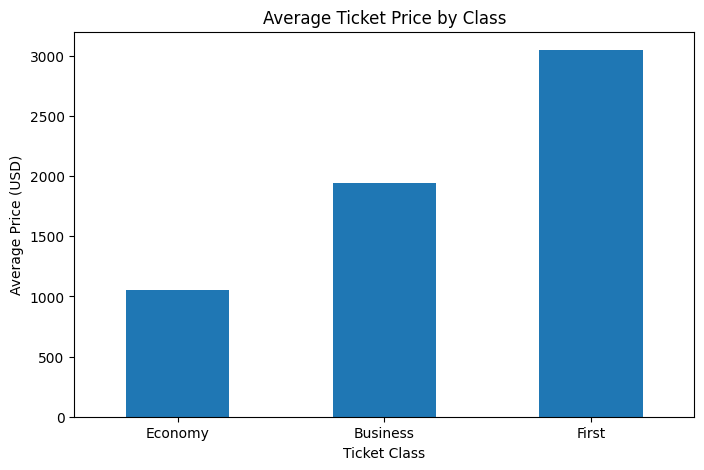

In [10]:
import matplotlib.pyplot as plt

avg_class = df.groupby("Class")["Price_USD"].mean().sort_values()

avg_class.plot(kind="bar", figsize=(8,5))
plt.title("Average Ticket Price by Class")
plt.xlabel("Ticket Class")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=0)
plt.show()

First class tickets are significantly more expensive than economy tickets, which aligns with typical airline pricing strategies.

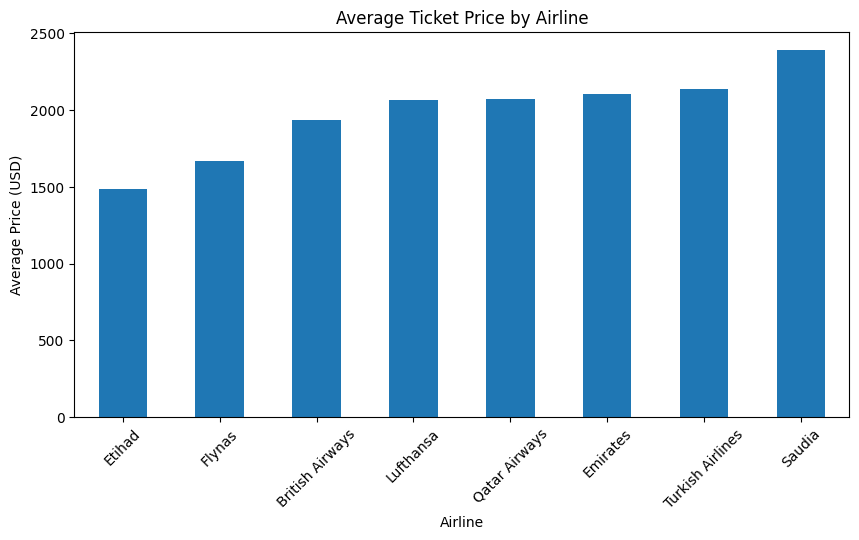

In [11]:
avg_airline = df.groupby("Airline")["Price_USD"].mean().sort_values()

avg_airline.plot(kind="bar", figsize=(10,5))
plt.title("Average Ticket Price by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=45)
plt.show()

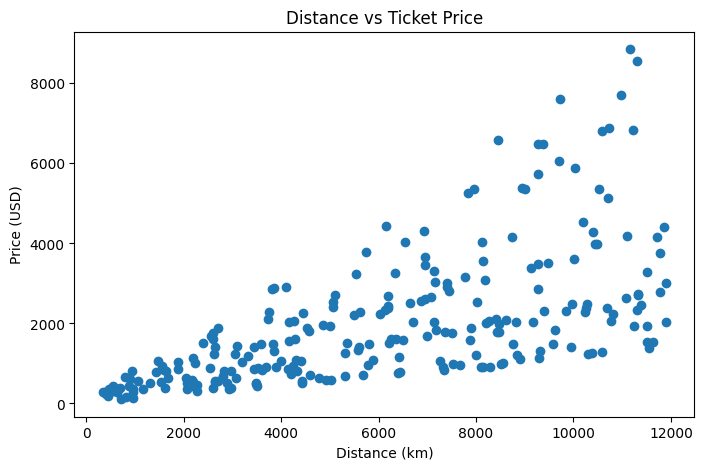

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(df["Distance_km"], df["Price_USD"])

plt.title("Distance vs Ticket Price")
plt.xlabel("Distance (km)")
plt.ylabel("Price (USD)")
plt.show()

Ticket prices generally increase with flight distance, but the relationship is not perfectly linear. Airline brand and ticket class also influence price.

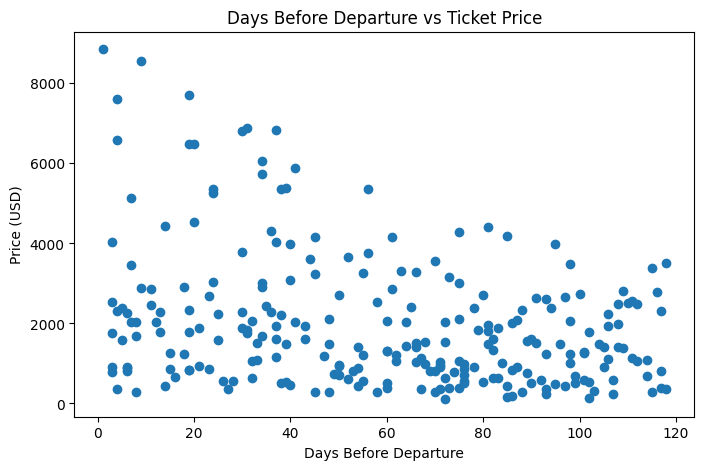

In [13]:
plt.figure(figsize=(8,5))
plt.scatter(df["Days_Before_Departure"], df["Price_USD"])

plt.title("Days Before Departure vs Ticket Price")
plt.xlabel("Days Before Departure")
plt.ylabel("Price (USD)")
plt.show()

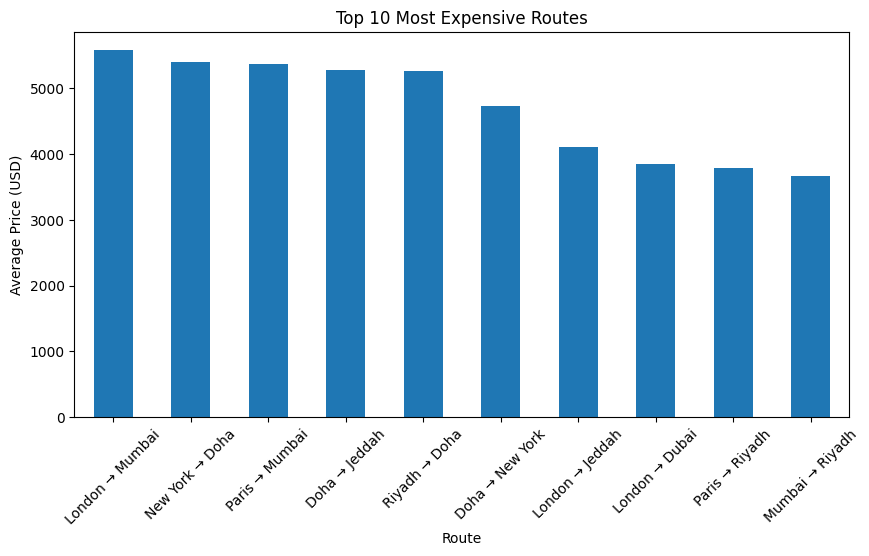

In [14]:
top_routes = df.groupby("Route")["Price_USD"].mean().sort_values(ascending=False).head(10)

top_routes.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Most Expensive Routes")
plt.xlabel("Route")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=45)
plt.show()

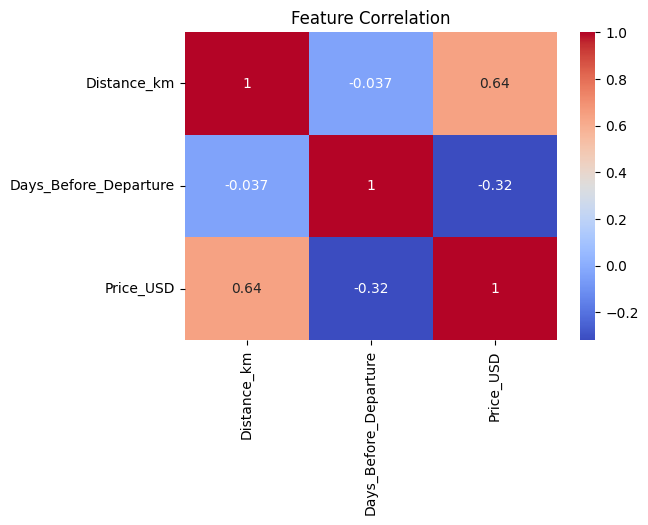

In [15]:
import seaborn as sns

corr = df[["Distance_km","Days_Before_Departure","Price_USD"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X = df.drop(["Ticket_ID","Price_USD","Route","Price_per_km"], axis=1)
y = df["Price_USD"]

categorical = ["Airline","Origin","Destination","Class"]
numeric = ["Distance_km","Days_Before_Departure"]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
], remainder="passthrough")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
model = Pipeline([
    ("prep", preprocessor),
    ("rf", RandomForestRegressor(random_state=42))
])

model.fit(X_train, y_train)

preds = model.predict(X_test)

In [18]:
# Get feature names from the model
feature_names = model.named_steps["prep"].get_feature_names_out()

# Get importance values
importances = model.named_steps["rf"].feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort values
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
31,remainder__Distance_km,0.491280
30,cat__Class_First,0.253059
32,remainder__Days_Before_Departure,0.138786
29,cat__Class_Economy,0.071236
28,cat__Class_Business,0.020360
5,cat__Airline_Qatar Airways,0.004230
13,cat__Origin_London,0.002238
10,cat__Origin_Dubai,0.001824
24,cat__Destination_Mumbai,0.001519
9,cat__Origin_Doha,0.001285


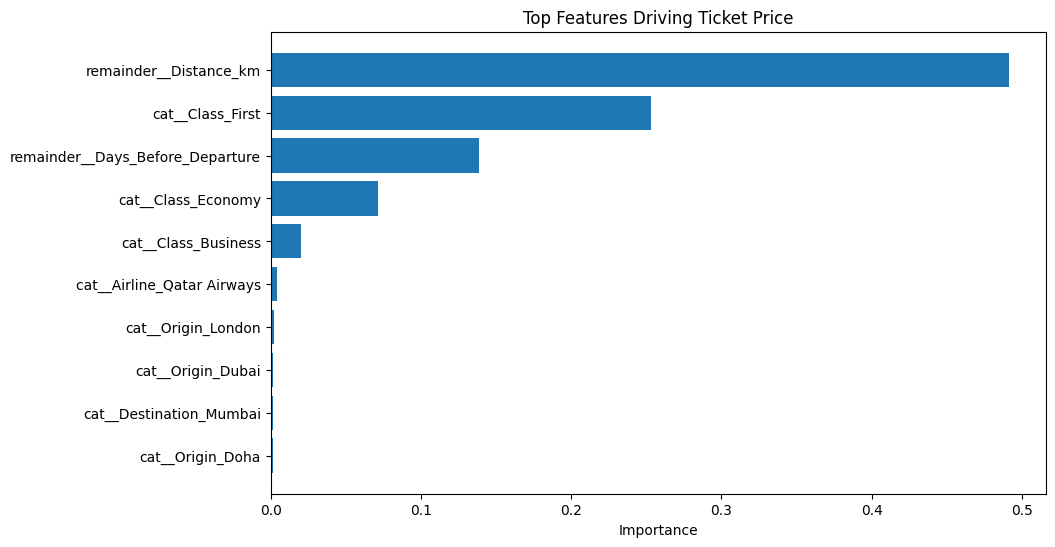

In [19]:
plt.figure(figsize=(10,6))

top_features = feature_importance.head(10)

plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.title("Top Features Driving Ticket Price")
plt.gca().invert_yaxis()

plt.show()

### Feature Importance Analysis

The Random Forest model highlights which variables most influence airline ticket prices.

Key drivers include:

• Ticket class (First / Business / Economy)  
• Flight distance  
• Airline brand  
• Booking timing before departure  

These results suggest that ticket pricing is primarily driven by service level (class) and route characteristics rather than booking timing alone.

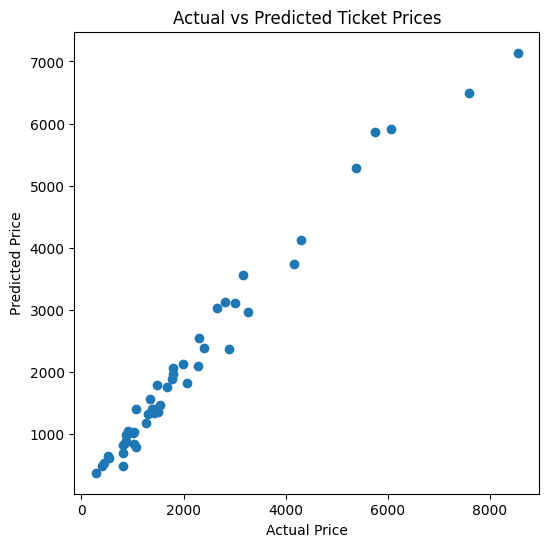

In [20]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, preds)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Ticket Prices")

plt.show()

In [21]:
model = Pipeline([
    ("prep", preprocessor),
    ("rf", RandomForestRegressor(random_state=42))
])

model.fit(X_train, y_train)

preds = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("R2:", r2_score(y_test, preds))

MAE: 203.85053199999987
R2: 0.9682964393028567


In [22]:
route_prices = (
    df.groupby(["Origin", "Destination"])["Price_USD"]
    .mean()
    .reset_index()
    .sort_values("Price_USD", ascending=False)
)

route_prices.head(10)

,Origin,Destination,Price_USD
47,London,Mumbai,5576.315000
60,New York,Doha,5393.520000
74,Paris,Mumbai,5367.820000
12,Doha,Jeddah,5281.280000
78,Riyadh,Doha,5264.140000
15,Doha,New York,4732.640000
46,London,Jeddah,4111.610000
44,London,Dubai,3846.280000
76,Paris,Riyadh,3791.686667
58,Mumbai,Riyadh,3668.135000


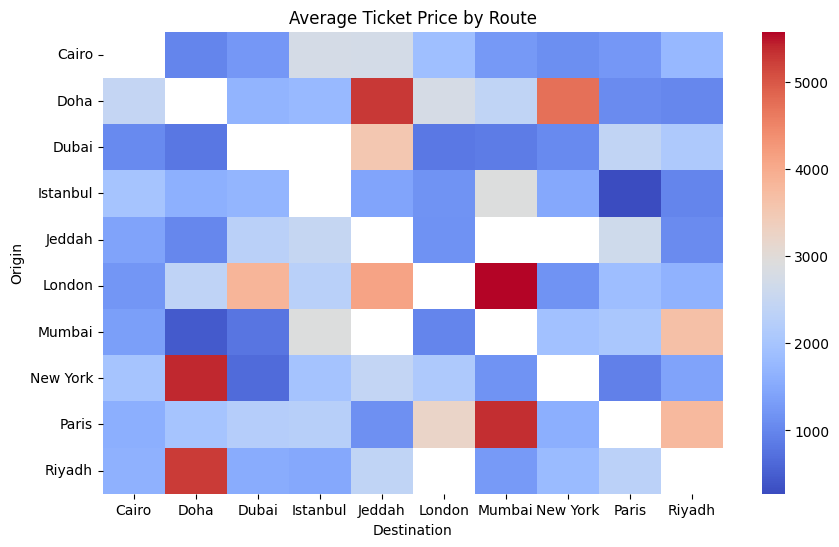

In [23]:
import seaborn as sns

route_matrix = df.pivot_table(
    values="Price_USD",
    index="Origin",
    columns="Destination",
    aggfunc="mean"
)

plt.figure(figsize=(10,6))

sns.heatmap(route_matrix, cmap="coolwarm", annot=False)

plt.title("Average Ticket Price by Route")
plt.xlabel("Destination")
plt.ylabel("Origin")

plt.show()

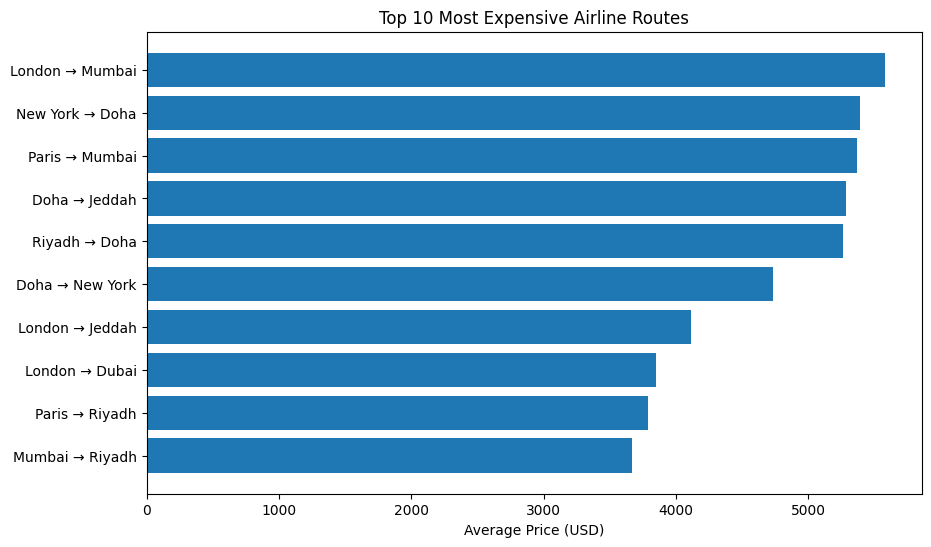

In [24]:
top_routes = route_prices.head(10)

plt.figure(figsize=(10,6))

routes = top_routes["Origin"] + " → " + top_routes["Destination"]

plt.barh(routes, top_routes["Price_USD"])

plt.xlabel("Average Price (USD)")
plt.title("Top 10 Most Expensive Airline Routes")

plt.gca().invert_yaxis()

plt.show()

### Route Pricing Insights

Some airline routes command significantly higher prices than others.  
These higher prices may be driven by:

• longer flight distances  
• premium airline carriers  
• higher demand routes  
• premium ticket classes  

Understanding route-level pricing can help airlines optimize revenue strategies and identify high-value markets.

## Project Summary

This project explored airline ticket pricing using Python to understand what factors influence airfare and whether ticket prices can be estimated using available data. The analysis examined airline carriers, flight routes, travel class, distance, and booking timing to uncover patterns in pricing behavior.

Several key insights emerged from the analysis. Ticket class had the strongest influence on price, with first and business class tickets consistently costing more than economy tickets. Flight distance also played an important role in determining price, though the relationship was not perfectly linear. Airline brand and specific routes contributed additional variation in pricing. Route-level analysis revealed that some city pairs command significantly higher prices, highlighting the role of market demand and airline positioning.

A machine learning model was also trained to estimate ticket prices based on the available features. The results demonstrate that predictive models can reasonably approximate ticket prices using route characteristics and service class information.

### Key Skills Demonstrated

**1. Data Exploration and Cleaning**  
The project began with structured data inspection, summary statistics, and validation checks to understand dataset structure and ensure data quality.

**2. Feature Engineering**  
New variables such as route combinations and price-per-distance metrics were created to extract deeper insights from the dataset.

**3. Data Visualization**  
Multiple charts and visualizations were used to explore pricing patterns across airlines, ticket classes, routes, and flight distances.

**4. Machine Learning for Prediction**  
A Random Forest regression model was implemented to predict airline ticket prices, demonstrating how predictive analytics can support pricing strategies.

**5. Business-Oriented Insights**  
The analysis translated technical results into practical insights relevant to airline pricing strategies, including route profitability and service-level pricing differences.

Overall, this project demonstrates how data analytics techniques can be applied to real-world pricing data to uncover insights, build predictive models, and support business decision-making.